
# Optimized CPU Conv2D Batch Performance — 20 Images

This notebook matches the style and output format of the CPU and FPGA batch notebooks, but it runs the same 5×5 Conv2D algorithms using an optimized CPU implementation.

Main implementation:

- **OpenCV `filter2D`** when `cv2` is available
- **NumPy vectorized fallback** when OpenCV is not available

It is designed to work on both:

- a normal laptop/PC CPU
- the PYNQ-Z2 ARM CPU

Expected folder structure:

```text
project_folder/
├── opencv_cpu_conv2d_performance_batch_20_assignment.ipynb
└── input/
    ├── 01.jpg / 01.png / 01
    ├── 02.jpg / 02.png / 02
    ├── ...
    └── 20.jpg / 20.png / 20
```

The notebook does not resize the images. It checks that every input image is already `640 × 640`.

The notebook has separate execution cells for:

1. Blur 5×5 batch results
2. Edge-emphasis 5×5 batch results
3. Final combined statistics and project-level summary


In [ ]:

from __future__ import annotations

import csv
import os
import platform
import sys
import time
import traceback
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple, Any

import numpy as np
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import display, Image as IPythonImage
    IPYTHON_DISPLAY_AVAILABLE = True
except Exception:
    IPYTHON_DISPLAY_AVAILABLE = False

try:
    from PIL import Image
    PIL_AVAILABLE = True
except Exception:
    PIL_AVAILABLE = False

try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    psutil = None
    PSUTIL_AVAILABLE = False

try:
    import cv2
    OPENCV_AVAILABLE = True
    OPENCV_IMPORT_ERROR = ""
except Exception as exc:
    cv2 = None
    OPENCV_AVAILABLE = False
    OPENCV_IMPORT_ERROR = str(exc)


# Configuration
# -----------------------------------------------------

OUTPUT_DIR = "opencv_cpu_outputs"
INPUT_DIR_NAME = "input"

EXPECTED_IMAGE_SIZE = (640, 640)       # width, height
EXPECTED_IMAGE_COUNT = 20
INPUT_IMAGE_STEMS = [f"{i:02d}" for i in range(1, EXPECTED_IMAGE_COUNT + 1)]
INPUT_EXTENSIONS = ["", ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

# Batch mode: one measured optimized CPU pass per image.
SAVE_IMAGES = True
SAVE_FIRST_N_OUTPUT_IMAGES = 20    

MAX_HEIGHT = 1080
MAX_WIDTH = 1920

#energy consumption measurement configuration
MANUAL_POWER_WATTS = None 

print("Environment")
print("-----------")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Optimized CPU execution mode: available")
print("OpenCV available:", OPENCV_AVAILABLE)
if OPENCV_AVAILABLE:
    try:
        print("OpenCV version:", cv2.__version__)
        print("OpenCV threads:", cv2.getNumThreads())
    except Exception:
        pass
else:
    print("OpenCV import note:", OPENCV_IMPORT_ERROR)
    print("Using NumPy vectorized fallback. Install opencv-python for the intended optimized OpenCV baseline.")
print("psutil available:", PSUTIL_AVAILABLE)

print("\nConfiguration")
print("-------------")
print("Input folder:", INPUT_DIR_NAME)
print("Expected image size:", EXPECTED_IMAGE_SIZE)
print("Expected image count:", EXPECTED_IMAGE_COUNT)
print("Manual power watts:", MANUAL_POWER_WATTS)


Environment
-----------
Python: 3.13.7
Platform: Windows-11-10.0.26200-SP0
Optimized CPU execution mode: available
OpenCV available: True
OpenCV version: 4.12.0
OpenCV threads: 8
psutil available: True

Configuration
-------------
Input folder: input
Expected image size: (640, 640)
Expected image count: 20
Manual power watts: None


In [ ]:


# Utility helpers and system sensors


def notebook_folder() -> Path:
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd().resolve()


def format_duration(seconds: float) -> str:
    total = int(round(max(0.0, seconds)))
    h = total // 3600
    m = (total % 3600) // 60
    s = total % 60
    if h:
        return f"{h}h {m:02d}m {s:02d}s"
    if m:
        return f"{m}m {s:02d}s"
    return f"{s}s"


def summarize_values(values: Sequence[float]) -> Dict[str, float]:
    arr = np.asarray(values, dtype=np.float64)
    if arr.size == 0:
        return {
            "mean": float("nan"),
            "median": float("nan"),
            "std": float("nan"),
            "min": float("nan"),
            "max": float("nan"),
            "sum": float("nan"),
        }
    return {
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "sum": float(np.sum(arr)),
    }


def save_uint8_image(path: Path, arr: np.ndarray) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if PIL_AVAILABLE:
        Image.fromarray(arr.astype(np.uint8), mode="L").save(path)
    else:
        plt.imsave(path, arr.astype(np.uint8), cmap="gray", vmin=0, vmax=255)


def _read_proc_meminfo() -> Dict[str, float]:
    values: Dict[str, float] = {}
    try:
        with open("/proc/meminfo", "r", encoding="utf-8") as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 2:
                    values[parts[0].rstrip(":")] = float(parts[1]) * 1024.0
    except Exception:
        pass
    return values


def read_temperatures_c() -> Dict[str, float]:
    temps: Dict[str, float] = {}

    # Common Linux thermal zones.
    for p in Path("/sys/class/thermal").glob("thermal_zone*/temp"):
        try:
            zone = p.parent.name
            type_path = p.parent / "type"
            label = type_path.read_text(errors="ignore").strip() if type_path.exists() else zone
            raw = float(p.read_text().strip())
            temp_c = raw / 1000.0 if raw > 1000 else raw
            temps[label] = temp_c
        except Exception:
            pass

    # hwmon temperature inputs.
    for p in Path("/sys/class/hwmon").glob("hwmon*/temp*_input"):
        try:
            label = p.parent.name + "_" + p.stem
            raw = float(p.read_text().strip())
            temp_c = raw / 1000.0 if raw > 1000 else raw
            temps[label] = temp_c
        except Exception:
            pass

    # psutil sensors, when available.
    if PSUTIL_AVAILABLE:
        try:
            sensor_map = psutil.sensors_temperatures(fahrenheit=False)
            for group, entries in sensor_map.items():
                for idx, entry in enumerate(entries):
                    name = entry.label or f"{group}_{idx}"
                    if entry.current is not None:
                        temps[name] = float(entry.current)
        except Exception:
            pass

    return temps

# to expose power consuption, just if it's available via Linux hwmon or IIO interfaces.
def read_power_watts() -> Dict[str, float]:

    powers: Dict[str, float] = {}

    # Linux hwmon power inputs.
    for p in Path("/sys/class/hwmon").glob("hwmon*/power*_input"):
        try:
            label = p.parent.name + "_" + p.stem
            raw = float(p.read_text().strip())
            if raw > 100000:
                watts = raw / 1_000_000.0
            elif raw > 1000:
                watts = raw / 1000.0
            else:
                watts = raw
            powers[label] = watts
        except Exception:
            pass

    # Some IIO power monitors expose voltage/current only.
    for dev in Path("/sys/bus/iio/devices").glob("iio:device*"):
        try:
            name_path = dev / "name"
            dev_name = name_path.read_text(errors="ignore").strip() if name_path.exists() else dev.name
            voltage_files = list(dev.glob("in_voltage*_input"))
            current_files = list(dev.glob("in_current*_input"))
            for vf in voltage_files:
                suffix = vf.name.replace("in_voltage", "").replace("_input", "")
                cf = dev / f"in_current{suffix}_input"
                if not cf.exists() and current_files:
                    cf = current_files[0]
                if cf.exists():
                    v_raw = float(vf.read_text().strip())
                    c_raw = float(cf.read_text().strip())

                    # Common convention: voltage in mV and current in mA.
                    volts = v_raw / 1000.0 if v_raw > 100 else v_raw
                    amps = c_raw / 1000.0 if c_raw > 10 else c_raw
                    powers[f"{dev_name}_ch{suffix}"] = volts * amps
        except Exception:
            pass

    if not powers and MANUAL_POWER_WATTS is not None:
        powers["manual_power_watts"] = float(MANUAL_POWER_WATTS)

    return powers


def system_snapshot(label: str) -> Dict[str, Any]:
    snap: Dict[str, Any] = {
        "label": label,
        "timestamp_s": time.time(),
        "cpu_percent": float("nan"),
        "ram_used_mb": float("nan"),
        "ram_total_mb": float("nan"),
        "ram_percent": float("nan"),
        "process_rss_mb": float("nan"),
        "loadavg_1min": float("nan"),
        "temperatures_c": read_temperatures_c(),
        "power_watts": read_power_watts(),
    }

    if PSUTIL_AVAILABLE:
        try:
            snap["cpu_percent"] = float(psutil.cpu_percent(interval=0.1))
            vm = psutil.virtual_memory()
            snap["ram_used_mb"] = float(vm.used) / (1024.0 * 1024.0)
            snap["ram_total_mb"] = float(vm.total) / (1024.0 * 1024.0)
            snap["ram_percent"] = float(vm.percent)
            snap["process_rss_mb"] = float(psutil.Process(os.getpid()).memory_info().rss) / (1024.0 * 1024.0)
        except Exception:
            pass
    else:
        meminfo = _read_proc_meminfo()
        if "MemTotal" in meminfo and "MemAvailable" in meminfo:
            total = meminfo["MemTotal"]
            used = total - meminfo["MemAvailable"]
            snap["ram_total_mb"] = total / (1024.0 * 1024.0)
            snap["ram_used_mb"] = used / (1024.0 * 1024.0)
            snap["ram_percent"] = 100.0 * used / total if total > 0 else float("nan")
        try:
            with open("/proc/self/statm", "r", encoding="utf-8") as f:
                pages = int(f.read().split()[1])
                snap["process_rss_mb"] = pages * os.sysconf("SC_PAGE_SIZE") / (1024.0 * 1024.0)
        except Exception:
            pass

    try:
        snap["loadavg_1min"] = float(os.getloadavg()[0])
    except Exception:
        pass

    return snap


def primary_temperature(snapshot: Dict[str, Any]) -> float:
    temps = snapshot.get("temperatures_c", {})
    if not temps:
        return float("nan")
    # Return highest observed CPU/SoC temperature as a conservative single value.
    return float(max(temps.values()))


def total_power_watts(snapshot: Dict[str, Any]) -> float:
    powers = snapshot.get("power_watts", {})
    if not powers:
        return float("nan")
    return float(sum(powers.values()))


def energy_joules(power_watts: float, seconds: float) -> float:
    if not np.isfinite(power_watts):
        return float("nan")
    return float(power_watts * seconds)


def print_system_snapshot(snap: Dict[str, Any]) -> None:
    temp = primary_temperature(snap)
    power = total_power_watts(snap)

    print(
        f"{snap['label']}: "
        f"CPU={snap['cpu_percent']:.1f}% | "
        f"RAM={snap['ram_used_mb']:.1f}/{snap['ram_total_mb']:.1f} MB "
        f"({snap['ram_percent']:.1f}%) | "
        f"Process={snap['process_rss_mb']:.1f} MB | "
        f"Load1={snap['loadavg_1min']:.2f} | "
        f"Temp={temp:.1f} C | "
        f"Power={power:.3f} W"
    )

    if not snap.get("power_watts"):
        print("  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.")


In [ ]:


# Kernels and image loading


KERNELS: Dict[str, Dict[str, object]] = {
    "blur5x5": {
        "display": "Blur 5x5",
        "kernel": np.ones((5, 5), dtype=np.int16),
        "divisor": 25,
        "bias": 0,
    },
    "edge_emphasis5x5": {
        "display": "Edge emphasis 5x5",
        "kernel": np.array(
            [
                [-1, -1, -1, -1, -1],
                [-1, 1, 1, 1, -1],
                [-1, 1, 16, 1, -1],
                [-1, 1, 1, 1, -1],
                [-1, -1, -1, -1, -1],
            ],
            dtype=np.int16,
        ),
        "divisor": 1,
        "bias": 0,
    },
}


def find_image_by_stem(input_dir: Path, stem: str) -> Path:
    for ext in INPUT_EXTENSIONS:
        p = input_dir / f"{stem}{ext}"
        if p.exists() and p.is_file():
            return p
    raise FileNotFoundError(
        f"Missing image '{stem}' in {input_dir}. "
        f"Checked extensions: {INPUT_EXTENSIONS}"
    )


def load_input_batch(folder: Path) -> List[Tuple[str, Path, np.ndarray]]:
    if not PIL_AVAILABLE:
        raise RuntimeError("Pillow/PIL is required to load the input image folder.")

    input_dir = folder / INPUT_DIR_NAME
    if not input_dir.exists():
        raise FileNotFoundError(f"Input folder not found: {input_dir}")

    expected_w, expected_h = EXPECTED_IMAGE_SIZE
    loaded: List[Tuple[str, Path, np.ndarray]] = []

    for stem in INPUT_IMAGE_STEMS:
        path = find_image_by_stem(input_dir, stem)
        img_pil = Image.open(path).convert("L")
        width, height = img_pil.size

        if (width, height) != (expected_w, expected_h):
            raise ValueError(
                f"Image {path.name} has size {width}x{height}, "
                f"but expected {expected_w}x{expected_h}. "
                "This notebook does not resize batch images."
            )

        arr = np.asarray(img_pil, dtype=np.uint8)
        loaded.append((stem, path, arr))

    print(f"Loaded {len(loaded)} images from {input_dir}")
    print("First image:", loaded[0][1].name, loaded[0][2].shape, loaded[0][2].dtype)
    print("Last image:", loaded[-1][1].name, loaded[-1][2].shape, loaded[-1][2].dtype)

    return loaded


In [ ]:


# Optimized CPU Conv2D implementation
# -----------------------------------------------

def optimized_cpu_backend_name() -> str:
    if OPENCV_AVAILABLE:
        return "OpenCV filter2D"
    return "NumPy vectorized fallback"


def apply_divisor_bias_clip(acc: np.ndarray, divisor: int, bias: int) -> np.ndarray:
    if divisor == 0:
        val = acc.astype(np.float64)
    else:
        # Match C/C++ integer division convention: truncation toward zero.
        val = np.trunc(acc.astype(np.float64) / float(divisor))

    val = val + int(bias)
    return np.clip(val, 0, 255).astype(np.uint8)


def conv2d_cpu_optimized(
    img: np.ndarray,
    kernel: np.ndarray,
    divisor: int,
    bias: int,
) -> np.ndarray:
    """
    Optimized CPU version of the same 5x5 Conv2D operation.

    It keeps the same output convention as the HLS accelerator:
    - uint8 grayscale input
    - uint8 grayscale output
    - 5x5 signed integer kernel
    - 2-pixel border copied unchanged
    - divisor and bias applied after accumulation
    - clipping to 0..255

    OpenCV filter2D is used when available. For these symmetric kernels, OpenCV's
    correlation operation is equivalent to convolution. The fallback uses NumPy's
    sliding-window view.
    """
    rows, cols = img.shape
    out = img.copy()

    if rows < 5 or cols < 5:
        return out

    if OPENCV_AVAILABLE:
        # Use float32 accumulation. The integer sums in this project are small
        # enough to be represented exactly for these kernels and uint8 inputs.
        acc = cv2.filter2D(
            src=img.astype(np.float32),
            ddepth=-1,
            kernel=kernel.astype(np.float32),
            anchor=(-1, -1),
            delta=0,
            borderType=cv2.BORDER_CONSTANT,
        )
        interior = apply_divisor_bias_clip(acc[2:rows - 2, 2:cols - 2], divisor, bias)
        out[2:rows - 2, 2:cols - 2] = interior
        return out

    # NumPy fallback: still much faster than pure nested Python on many systems,
    # but OpenCV is the intended optimized baseline.
    from numpy.lib.stride_tricks import sliding_window_view

    windows = sliding_window_view(img.astype(np.int32), (5, 5))
    acc = np.einsum("ijmn,mn->ij", windows, kernel.astype(np.int32), optimize=True)
    interior = apply_divisor_bias_clip(acc, divisor, bias)
    out[2:rows - 2, 2:cols - 2] = interior
    return out


def run_optimized_cpu_once(
    img: np.ndarray,
    kernel: np.ndarray,
    divisor: int,
    bias: int,
) -> Tuple[np.ndarray, float, float]:
    """
    Returns:
    - output image
    - optimized CPU processing time in ms
    - optimized CPU end-to-end time in ms

    For CPU-only mode, processing time and end-to-end time are almost the same.
    End-to-end includes the small function call/timing wrapper overhead.
    """
    t_total0 = time.perf_counter()

    t_kernel0 = time.perf_counter()
    out = conv2d_cpu_optimized(img, kernel, divisor, bias)
    t_kernel1 = time.perf_counter()

    t_total1 = time.perf_counter()

    return out, (t_kernel1 - t_kernel0) * 1000.0, (t_total1 - t_total0) * 1000.0


In [ ]:

# Batch execution helpers
# -------------------------------------------

ALL_BATCH_RESULTS: Dict[str, Dict[str, Any]] = {}


def run_kernel_on_batch(kernel_key: str) -> Dict[str, Any]:
    if kernel_key not in KERNELS:
        raise ValueError(f"Unknown kernel: {kernel_key}. Available kernels: {list(KERNELS.keys())}")

    folder = notebook_folder()
    out_dir = folder / OUTPUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)

    batch = load_input_batch(folder)

    cfg = KERNELS[kernel_key]
    kernel = cfg["kernel"]
    divisor = int(cfg["divisor"])
    bias = int(cfg["bias"])
    display_name = str(cfg["display"])
    backend = optimized_cpu_backend_name()

    kernel_output_dir = out_dir / kernel_key
    kernel_output_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print(f"Optimized CPU batch run: {display_name}")
    print("=" * 100)
    print("Backend:", backend)
    print("Images:", len(batch))
    print("Image size:", f"{EXPECTED_IMAGE_SIZE[0]}x{EXPECTED_IMAGE_SIZE[1]}")
    print("Output folder:", kernel_output_dir)

    before = system_snapshot(f"before_{kernel_key}")
    print_system_snapshot(before)

    per_image_rows: List[Dict[str, Any]] = []
    processing_times_ms: List[float] = []
    total_times_ms: List[float] = []

    batch_wall_start = time.perf_counter()

    print("\nMeasured batch processing")
    for idx, (stem, path, img) in enumerate(batch, start=1):
        cpu_out, processing_ms, total_ms = run_optimized_cpu_once(img, kernel, divisor, bias)

        processing_times_ms.append(processing_ms)
        total_times_ms.append(total_ms)

        if SAVE_IMAGES and idx <= SAVE_FIRST_N_OUTPUT_IMAGES:
            save_uint8_image(kernel_output_dir / f"{stem}_{kernel_key}_optimized_cpu.png", cpu_out)

        out_min = int(cpu_out.min())
        out_max = int(cpu_out.max())
        out_mean = float(cpu_out.mean())

        row = {
            "image_id": stem,
            "image_file": path.name,
            "kernel_key": kernel_key,
            "kernel_display": display_name,
            "backend": backend,
            "rows": int(img.shape[0]),
            "cols": int(img.shape[1]),
            "pixels": int(img.size),
            "optimized_cpu_processing_ms": float(processing_ms),
            "optimized_cpu_total_ms": float(total_ms),
            "output_min": out_min,
            "output_max": out_max,
            "output_mean": out_mean,
            "output_all_zero": bool(out_max == 0),
        }
        per_image_rows.append(row)

        print(
            f"  {idx:02d}/{len(batch)} {path.name}: "
            f"processing={processing_ms:.3f} ms, total={total_ms:.3f} ms, "
            f"out min/max/mean={out_min}/{out_max}/{out_mean:.2f}"
        )

    batch_wall_s = time.perf_counter() - batch_wall_start

    after = system_snapshot(f"after_{kernel_key}")
    print_system_snapshot(after)

    processing_stats = summarize_values(processing_times_ms)
    total_stats = summarize_values(total_times_ms)

    total_pixels = int(sum(row["pixels"] for row in per_image_rows))
    total_processing_s = processing_stats["sum"] / 1000.0
    total_end_to_end_s = total_stats["sum"] / 1000.0

    processing_mpix_s = total_pixels / total_processing_s / 1_000_000.0 if total_processing_s > 0 else float("nan")
    total_mpix_s = total_pixels / total_end_to_end_s / 1_000_000.0 if total_end_to_end_s > 0 else float("nan")

    power_before_w = total_power_watts(before)
    power_after_w = total_power_watts(after)
    avg_power_w = float(np.nanmean([power_before_w, power_after_w])) if np.isfinite(power_before_w) or np.isfinite(power_after_w) else float("nan")

    energy_processing_j = energy_joules(avg_power_w, total_processing_s)
    energy_total_j = energy_joules(avg_power_w, total_end_to_end_s)
    energy_wall_j = energy_joules(avg_power_w, batch_wall_s)

    result = {
        "processor": "Optimized CPU",
        "backend": backend,
        "opencv_available": OPENCV_AVAILABLE,
        "opencv_version": cv2.__version__ if OPENCV_AVAILABLE else "N/A",
        "platform": platform.platform(),
        "kernel_key": kernel_key,
        "kernel_display": display_name,
        "image_count": len(batch),
        "image_width": EXPECTED_IMAGE_SIZE[0],
        "image_height": EXPECTED_IMAGE_SIZE[1],
        "total_pixels": total_pixels,
        "optimized_cpu_processing_total_ms": processing_stats["sum"],
        "optimized_cpu_processing_mean_ms": processing_stats["mean"],
        "optimized_cpu_processing_median_ms": processing_stats["median"],
        "optimized_cpu_processing_std_ms": processing_stats["std"],
        "optimized_cpu_processing_min_ms": processing_stats["min"],
        "optimized_cpu_processing_max_ms": processing_stats["max"],
        "optimized_cpu_end_to_end_total_ms": total_stats["sum"],
        "optimized_cpu_end_to_end_mean_ms": total_stats["mean"],
        "optimized_cpu_end_to_end_median_ms": total_stats["median"],
        "optimized_cpu_end_to_end_std_ms": total_stats["std"],
        "optimized_cpu_end_to_end_min_ms": total_stats["min"],
        "optimized_cpu_end_to_end_max_ms": total_stats["max"],
        "batch_wall_time_s": batch_wall_s,
        "optimized_cpu_processing_throughput_mpix_s": processing_mpix_s,
        "optimized_cpu_end_to_end_throughput_mpix_s": total_mpix_s,
        "cpu_load_before_percent": before["cpu_percent"],
        "cpu_load_after_percent": after["cpu_percent"],
        "ram_used_before_mb": before["ram_used_mb"],
        "ram_used_after_mb": after["ram_used_mb"],
        "ram_percent_before": before["ram_percent"],
        "ram_percent_after": after["ram_percent"],
        "process_rss_before_mb": before["process_rss_mb"],
        "process_rss_after_mb": after["process_rss_mb"],
        "temperature_before_c": primary_temperature(before),
        "temperature_after_c": primary_temperature(after),
        "power_before_w": power_before_w,
        "power_after_w": power_after_w,
        "average_power_w": avg_power_w,
        "energy_processing_j": energy_processing_j,
        "energy_end_to_end_j": energy_total_j,
        "energy_wall_j": energy_wall_j,
        "cpu_runtime_load_percent": after["cpu_percent"],
        "cpu_runtime_load_note": "CPU load is sampled before and after the batch. OpenCV may use internal native code and may use multiple threads depending on the build.",
        "power_note": "Energy is computed only if system power sensors are available or MANUAL_POWER_WATTS is set. Otherwise it is N/A.",
        "per_image": per_image_rows,
    }

    ALL_BATCH_RESULTS[kernel_key] = result

    # Save per-kernel CSV.
    per_image_csv = kernel_output_dir / f"{kernel_key}_per_image_results.csv"
    with per_image_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(per_image_rows[0].keys()))
        writer.writeheader()
        writer.writerows(per_image_rows)

    summary_csv = kernel_output_dir / f"{kernel_key}_summary.csv"
    flat_result = {k: v for k, v in result.items() if k != "per_image"}
    with summary_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(flat_result.keys()))
        writer.writeheader()
        writer.writerow(flat_result)

    # Plot per-image times.
    labels = [row["image_id"] for row in per_image_rows]
    x = np.arange(len(labels), dtype=np.float64)
    width = 0.35

    plt.figure(figsize=(max(12, len(labels) * 0.55), 5))
    plt.bar(x - width / 2, processing_times_ms, width, label="Optimized CPU processing")
    plt.bar(x + width / 2, total_times_ms, width, label="Optimized CPU end-to-end")
    plt.xticks(x, labels)
    plt.ylabel("Time (ms)")
    plt.title(f"{display_name} optimized CPU processing time per image")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plot_path = kernel_output_dir / f"{kernel_key}_per_image_timing.png"
    plt.savefig(plot_path, dpi=180)
    plt.show()

    print("\n" + "=" * 100)
    print(f"{display_name} batch summary")
    print("=" * 100)
    print(f"Backend:                          {backend}")
    print(f"Images processed:                 {len(batch)}")
    print(f"Total pixels processed:           {total_pixels:,}")
    print(f"Optimized CPU processing total:   {processing_stats['sum']:.3f} ms")
    print(f"Optimized CPU end-to-end total:   {total_stats['sum']:.3f} ms")
    print(f"Batch wall time:                  {format_duration(batch_wall_s)} ({batch_wall_s:.3f} s)")
    print(f"Optimized CPU mean per image:     {processing_stats['mean']:.3f} ms")
    print(f"Optimized end-to-end mean/image:  {total_stats['mean']:.3f} ms")
    print(f"Processing throughput:            {processing_mpix_s:.3f} MPixels/s")
    print(f"End-to-end throughput:            {total_mpix_s:.3f} MPixels/s")
    print(f"Temperature before/after:         {primary_temperature(before):.1f} C / {primary_temperature(after):.1f} C")
    print(f"CPU load before/after:            {before['cpu_percent']:.1f}% / {after['cpu_percent']:.1f}%")
    print(f"RAM load before/after:            {before['ram_percent']:.1f}% / {after['ram_percent']:.1f}%")
    print(f"Power before/after:               {power_before_w:.3f} W / {power_after_w:.3f} W")
    print(f"Energy, processing time:          {energy_processing_j:.6f} J")
    print(f"Energy, end-to-end time:          {energy_total_j:.6f} J")
    print(f"CPU runtime load:                 {after['cpu_percent']:.1f}% snapshot")
    print(f"Per-image CSV:                    {per_image_csv}")
    print(f"Summary CSV:                      {summary_csv}")
    print(f"Timing plot:                      {plot_path}")

    if any(row["output_all_zero"] for row in per_image_rows):
        print("\nWarning: at least one optimized CPU output image is all zero.")

    return result


Loaded 20 images from C:\Users\Iva\Desktop\final_Files\input
First image: 01.jpg (640, 640) uint8
Last image: 20.jpg (640, 640) uint8

Optimized CPU batch run: Blur 5x5
Backend: OpenCV filter2D
Images: 20
Image size: 640x640
Output folder: C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\blur5x5
before_blur5x5: CPU=0.0% | RAM=6663.1/7916.5 MB (84.2%) | Process=122.8 MB | Load1=nan | Temp=nan C | Power=nan W
  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.

Measured batch processing
  01/20 01.jpg: processing=42.856 ms, total=42.857 ms, out min/max/mean=12/255/196.72
  02/20 02.jpg: processing=9.532 ms, total=9.533 ms, out min/max/mean=53/255/229.49


C:\Users\Iva\AppData\Local\Temp\ipykernel_16152\204186114.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr.astype(np.uint8), mode="L").save(path)


  03/20 03.jpg: processing=10.431 ms, total=10.431 ms, out min/max/mean=34/255/200.44
  04/20 04.jpg: processing=8.141 ms, total=8.141 ms, out min/max/mean=41/255/220.02
  05/20 05.jpg: processing=9.838 ms, total=9.838 ms, out min/max/mean=53/255/227.59
  06/20 06.jpg: processing=9.234 ms, total=9.235 ms, out min/max/mean=43/255/223.74
  07/20 07.jpg: processing=9.257 ms, total=9.258 ms, out min/max/mean=53/255/228.15
  08/20 08.jpg: processing=7.473 ms, total=7.473 ms, out min/max/mean=2/255/207.44
  09/20 09.jpg: processing=7.525 ms, total=7.525 ms, out min/max/mean=53/255/211.20
  10/20 10.jpg: processing=8.514 ms, total=8.514 ms, out min/max/mean=45/255/211.25
  11/20 11.jpg: processing=9.796 ms, total=9.796 ms, out min/max/mean=53/255/215.05
  12/20 12.jpg: processing=9.593 ms, total=9.594 ms, out min/max/mean=24/255/218.74
  13/20 13.jpg: processing=9.655 ms, total=9.655 ms, out min/max/mean=53/255/220.64
  14/20 14.jpg: processing=9.622 ms, total=9.623 ms, out min/max/mean=53/25

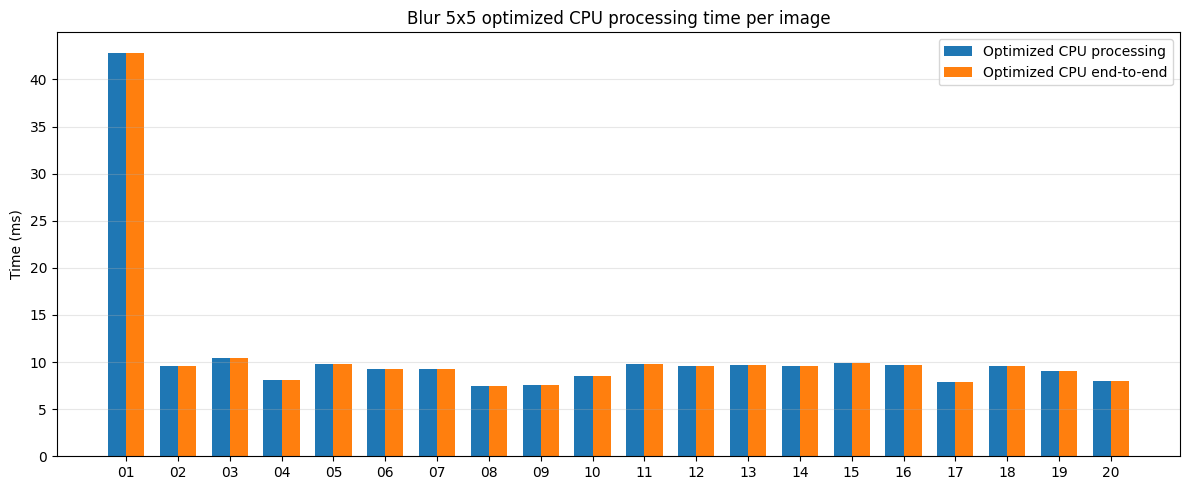


Blur 5x5 batch summary
Backend:                          OpenCV filter2D
Images processed:                 20
Total pixels processed:           8,192,000
Optimized CPU processing total:   215.500 ms
Optimized CPU end-to-end total:   215.510 ms
Batch wall time:                  1s (0.583 s)
Optimized CPU mean per image:     10.775 ms
Optimized end-to-end mean/image:  10.776 ms
Processing throughput:            38.014 MPixels/s
End-to-end throughput:            38.012 MPixels/s
Temperature before/after:         nan C / nan C
CPU load before/after:            0.0% / 38.0%
RAM load before/after:            84.2% / 84.2%
Power before/after:               nan W / nan W
Energy, processing time:          nan J
Energy, end-to-end time:          nan J
CPU runtime load:                 38.0% snapshot
Per-image CSV:                    C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\blur5x5\blur5x5_per_image_results.csv
Summary CSV:                      C:\Users\Iva\Desktop\final_Files\opencv_

In [ ]:

# Cell 1: Blur 5x5 results on 20 images
# -------------------------------------------------------

try:
    blur_batch_result = run_kernel_on_batch("blur5x5")
except Exception:
    print("Blur batch run failed.")
    traceback.print_exc()
    blur_batch_result = None


Loaded 20 images from C:\Users\Iva\Desktop\final_Files\input
First image: 01.jpg (640, 640) uint8
Last image: 20.jpg (640, 640) uint8

Optimized CPU batch run: Edge emphasis 5x5
Backend: OpenCV filter2D
Images: 20
Image size: 640x640
Output folder: C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\edge_emphasis5x5
before_edge_emphasis5x5: CPU=53.8% | RAM=6669.7/7916.5 MB (84.3%) | Process=128.2 MB | Load1=nan | Temp=nan C | Power=nan W
  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.

Measured batch processing
  01/20 01.jpg: processing=21.167 ms, total=21.168 ms, out min/max/mean=0/255/252.23
  02/20 02.jpg: processing=15.545 ms, total=15.546 ms, out min/max/mean=0/255/254.20
  03/20 03.jpg: processing=8.309 ms, total=8.310 ms, out min/max/mean=0/255/251.03
  04/20 04.jpg: processing=8.087 ms, total=8.087 ms, out min/max/mean=0/255/252.86
  05/20 05.jpg: processing=9.814 ms, total=9.814 ms, out min/max/mean=0/255/253.75
  06/20 06.jpg: processing=9

C:\Users\Iva\AppData\Local\Temp\ipykernel_16152\204186114.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr.astype(np.uint8), mode="L").save(path)


  11/20 11.jpg: processing=15.531 ms, total=15.531 ms, out min/max/mean=0/255/253.60
  12/20 12.jpg: processing=13.700 ms, total=13.701 ms, out min/max/mean=0/255/251.64
  13/20 13.jpg: processing=10.772 ms, total=10.773 ms, out min/max/mean=0/255/253.86
  14/20 14.jpg: processing=9.519 ms, total=9.519 ms, out min/max/mean=0/255/252.96
  15/20 15.jpg: processing=9.952 ms, total=9.953 ms, out min/max/mean=0/255/251.82
  16/20 16.jpg: processing=12.066 ms, total=12.067 ms, out min/max/mean=0/255/250.56
  17/20 17.jpg: processing=9.885 ms, total=9.887 ms, out min/max/mean=0/255/252.00
  18/20 18.jpg: processing=10.307 ms, total=10.307 ms, out min/max/mean=0/255/253.73
  19/20 19.jpg: processing=10.408 ms, total=10.409 ms, out min/max/mean=0/255/253.25
  20/20 20.jpg: processing=10.420 ms, total=10.420 ms, out min/max/mean=0/255/254.04
after_edge_emphasis5x5: CPU=34.0% | RAM=6677.2/7916.5 MB (84.3%) | Process=128.6 MB | Load1=nan | Temp=nan C | Power=nan W
  Power sensor: not available. En

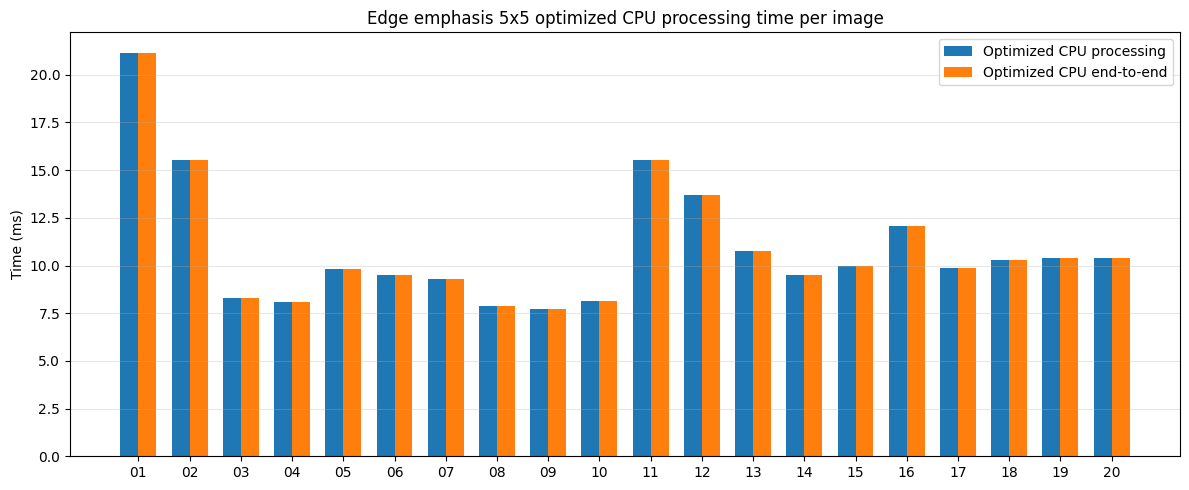


Edge emphasis 5x5 batch summary
Backend:                          OpenCV filter2D
Images processed:                 20
Total pixels processed:           8,192,000
Optimized CPU processing total:   218.002 ms
Optimized CPU end-to-end total:   218.017 ms
Batch wall time:                  0s (0.384 s)
Optimized CPU mean per image:     10.900 ms
Optimized end-to-end mean/image:  10.901 ms
Processing throughput:            37.578 MPixels/s
End-to-end throughput:            37.575 MPixels/s
Temperature before/after:         nan C / nan C
CPU load before/after:            53.8% / 34.0%
RAM load before/after:            84.3% / 84.3%
Power before/after:               nan W / nan W
Energy, processing time:          nan J
Energy, end-to-end time:          nan J
CPU runtime load:                 34.0% snapshot
Per-image CSV:                    C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\edge_emphasis5x5\edge_emphasis5x5_per_image_results.csv
Summary CSV:                      C:\Users\Iva

In [7]:

# =============================================================================
# Cell 2: Edge-emphasis 5x5 results on 20 images
# =============================================================================

try:
    edge_batch_result = run_kernel_on_batch("edge_emphasis5x5")
except Exception:
    print("Edge-emphasis batch run failed.")
    traceback.print_exc()
    edge_batch_result = None



Combined optimized CPU batch statistics
Saved combined CSV: C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\combined_optimized_cpu_batch_statistics.csv
Saved text summary: C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\combined_optimized_cpu_batch_summary.txt

Blur 5x5
--------
Backend:                        OpenCV filter2D
Images processed:               20
Total pixels:                   8,192,000
Optimized CPU processing total: 215.500 ms
Optimized CPU end-to-end total: 215.510 ms
Batch wall time:                0.583 s
Processing throughput:          38.014 MPixels/s
End-to-end throughput:          38.012 MPixels/s
Temperature before/after:       nan C / nan C
CPU load before/after:          0.0% / 38.0%
RAM load before/after:          84.2% / 84.2%
Average power:                  nan W
Energy end-to-end:              nan J
CPU runtime load:               38.0% snapshot

Edge emphasis 5x5
-----------------
Backend:                        OpenCV filter2D
Images processed:

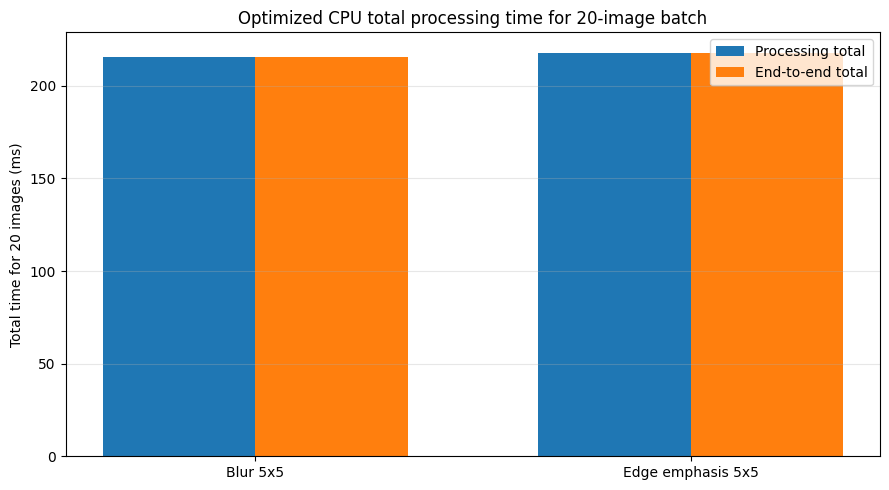

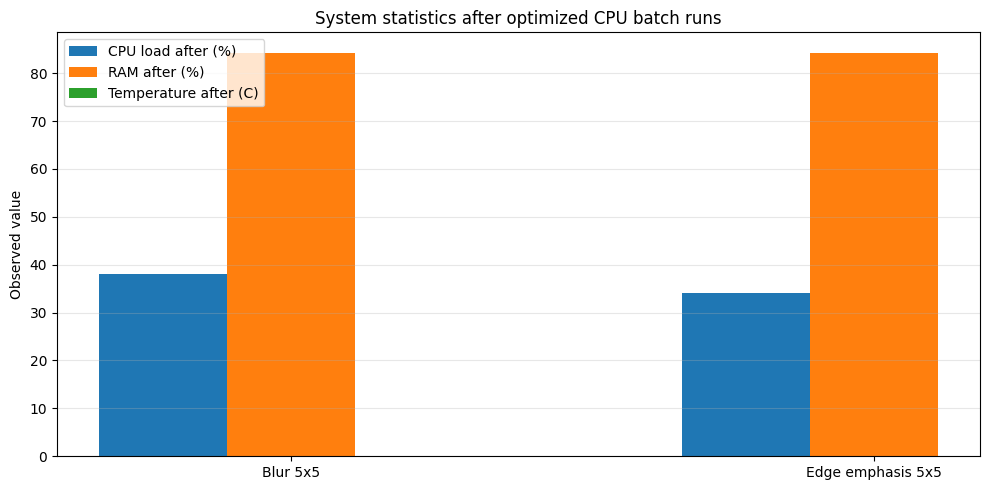

Saved timing chart: C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\combined_total_timing.png
Saved system stats chart: C:\Users\Iva\Desktop\final_Files\opencv_cpu_outputs\combined_system_statistics.png


In [ ]:

# Cell 3: Final combined statistics
# -----------------------------------------------

def save_combined_statistics() -> None:
    folder = notebook_folder()
    out_dir = folder / OUTPUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)

    results = [r for r in ALL_BATCH_RESULTS.values() if r is not None]
    if not results:
        print("No batch results found. Run the blur and edge-emphasis cells first.")
        return

    summary_rows = []
    for r in results:
        row = {k: v for k, v in r.items() if k != "per_image"}
        summary_rows.append(row)

    combined_csv = out_dir / "combined_optimized_cpu_batch_statistics.csv"
    with combined_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()))
        writer.writeheader()
        writer.writerows(summary_rows)

    # Text summary for report/presentation.
    summary_txt = out_dir / "combined_optimized_cpu_batch_summary.txt"
    with summary_txt.open("w", encoding="utf-8") as f:
        f.write("Optimized CPU Conv2D batch performance summary\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Input set: {EXPECTED_IMAGE_COUNT} images from ./{INPUT_DIR_NAME}/\n")
        f.write(f"Image size: {EXPECTED_IMAGE_SIZE[0]}x{EXPECTED_IMAGE_SIZE[1]}\n")
        f.write(f"Platform: {platform.platform()}\n")
        f.write(f"Backend: {optimized_cpu_backend_name()}\n")
        if OPENCV_AVAILABLE:
            f.write(f"OpenCV version: {cv2.__version__}\n")
        f.write("\n")

        for r in results:
            f.write(f"{r['kernel_display']}\n")
            f.write("-" * 40 + "\n")
            f.write(f"Backend: {r['backend']}\n")
            f.write(f"Images processed: {r['image_count']}\n")
            f.write(f"Total pixels: {r['total_pixels']:,}\n")
            f.write(f"Optimized CPU processing total time: {r['optimized_cpu_processing_total_ms']:.3f} ms\n")
            f.write(f"Optimized CPU end-to-end total time: {r['optimized_cpu_end_to_end_total_ms']:.3f} ms\n")
            f.write(f"Wall time: {r['batch_wall_time_s']:.3f} s\n")
            f.write(f"Processing throughput: {r['optimized_cpu_processing_throughput_mpix_s']:.3f} MPixels/s\n")
            f.write(f"End-to-end throughput: {r['optimized_cpu_end_to_end_throughput_mpix_s']:.3f} MPixels/s\n")
            f.write(f"Temperature before/after: {r['temperature_before_c']:.1f} C / {r['temperature_after_c']:.1f} C\n")
            f.write(f"CPU load before/after: {r['cpu_load_before_percent']:.1f}% / {r['cpu_load_after_percent']:.1f}%\n")
            f.write(f"RAM load before/after: {r['ram_percent_before']:.1f}% / {r['ram_percent_after']:.1f}%\n")
            f.write(f"Average power: {r['average_power_w']:.6f} W\n")
            f.write(f"Energy end-to-end: {r['energy_end_to_end_j']:.6f} J\n")
            f.write(f"CPU runtime load note: {r['cpu_runtime_load_note']}\n")
            f.write(f"Power note: {r['power_note']}\n\n")

    print("\n" + "=" * 100)
    print("Combined optimized CPU batch statistics")
    print("=" * 100)
    print(f"Saved combined CSV: {combined_csv}")
    print(f"Saved text summary: {summary_txt}")

    for r in results:
        print("\n" + r["kernel_display"])
        print("-" * len(r["kernel_display"]))
        print(f"Backend:                        {r['backend']}")
        print(f"Images processed:               {r['image_count']}")
        print(f"Total pixels:                   {r['total_pixels']:,}")
        print(f"Optimized CPU processing total: {r['optimized_cpu_processing_total_ms']:.3f} ms")
        print(f"Optimized CPU end-to-end total: {r['optimized_cpu_end_to_end_total_ms']:.3f} ms")
        print(f"Batch wall time:                {r['batch_wall_time_s']:.3f} s")
        print(f"Processing throughput:          {r['optimized_cpu_processing_throughput_mpix_s']:.3f} MPixels/s")
        print(f"End-to-end throughput:          {r['optimized_cpu_end_to_end_throughput_mpix_s']:.3f} MPixels/s")
        print(f"Temperature before/after:       {r['temperature_before_c']:.1f} C / {r['temperature_after_c']:.1f} C")
        print(f"CPU load before/after:          {r['cpu_load_before_percent']:.1f}% / {r['cpu_load_after_percent']:.1f}%")
        print(f"RAM load before/after:          {r['ram_percent_before']:.1f}% / {r['ram_percent_after']:.1f}%")
        print(f"Average power:                  {r['average_power_w']:.6f} W")
        print(f"Energy end-to-end:              {r['energy_end_to_end_j']:.6f} J")
        print(f"CPU runtime load:               {r['cpu_runtime_load_percent']:.1f}% snapshot")

    # Combined timing chart.
    labels = [r["kernel_display"] for r in results]
    x = np.arange(len(results), dtype=np.float64)
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, [r["optimized_cpu_processing_total_ms"] for r in results], width, label="Processing total")
    plt.bar(x + width / 2, [r["optimized_cpu_end_to_end_total_ms"] for r in results], width, label="End-to-end total")
    plt.xticks(x, labels)
    plt.ylabel("Total time for 20 images (ms)")
    plt.title("Optimized CPU total processing time for 20-image batch")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    chart_path = out_dir / "combined_total_timing.png"
    plt.savefig(chart_path, dpi=180)
    plt.show()

    # System statistics chart.
    plt.figure(figsize=(10, 5))
    x = np.arange(len(results), dtype=np.float64)
    width = 0.22
    plt.bar(x - width, [r["cpu_load_after_percent"] for r in results], width, label="CPU load after (%)")
    plt.bar(x, [r["ram_percent_after"] for r in results], width, label="RAM after (%)")
    plt.bar(x + width, [r["temperature_after_c"] for r in results], width, label="Temperature after (C)")
    plt.xticks(x, labels)
    plt.ylabel("Observed value")
    plt.title("System statistics after optimized CPU batch runs")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    stats_chart_path = out_dir / "combined_system_statistics.png"
    plt.savefig(stats_chart_path, dpi=180)
    plt.show()

    print(f"Saved timing chart: {chart_path}")
    print(f"Saved system stats chart: {stats_chart_path}")


save_combined_statistics()
